In [ ]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.interpolate import interp1d
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [ ]:
def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def astar(grid, start, goal):

    rows, cols = grid.shape

    open_set = []
    heapq.heappush(open_set, (0, start))

    came_from = {}

    g_score = {start: 0}
    f_score = {start: heuristic(start, goal)}

    while open_set:

        current = heapq.heappop(open_set)[1]

        if current == goal:

            path = []

            while current in came_from:
                path.append(current)
                current = came_from[current]

            path.append(start)

            return path[::-1]

        neighbors = [
            (current[0]+1, current[1]),
            (current[0]-1, current[1]),
            (current[0], current[1]+1),
            (current[0], current[1]-1)
        ]

        for neighbor in neighbors:

            r, c = neighbor

            if r < 0 or r >= rows:
                continue

            if c < 0 or c >= cols:
                continue

            if grid[r, c] == 1:
                continue

            tentative_g = g_score[current] + 1

            if neighbor not in g_score or tentative_g < g_score[neighbor]:

                came_from[neighbor] = current
                g_score[neighbor] = tentative_g

                f_score[neighbor] = (
                    tentative_g +
                    heuristic(neighbor, goal)
                )

                heapq.heappush(
                    open_set,
                    (f_score[neighbor], neighbor)
                )

    return None

In [ ]:
import shutil
input_size=32
#shutil.rmtree("dataset")
os.makedirs("dataset")
mapa = np.random.choice(
    [0,1],
    size=(input_size,input_size),
    p=[0.8,0.2]
)

inicio = (2,3)
meta = (17,15)

path = astar(mapa, inicio, meta)

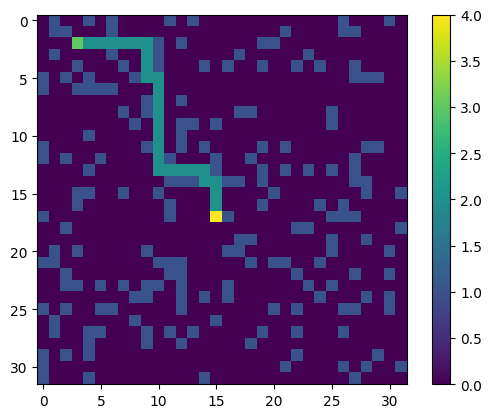

In [ ]:
vis = mapa.copy()

if path is not None:
    for p in path:
        vis[p] = 2

vis[inicio] = 3
vis[meta] = 4

plt.imshow(vis)
plt.colorbar()
plt.show()

In [ ]:
def generar_mapa(filas=input_size, columnas=input_size, prob_obstaculo=0.3):

    mapa = np.random.choice(
        [0, 1],
        size=(filas, columnas),
        p=[1-prob_obstaculo, prob_obstaculo]
    )

    return mapa

def punto_libre(mapa):

    while True:

        x = np.random.randint(0, mapa.shape[0])
        y = np.random.randint(0, mapa.shape[1])

        if mapa[x,y] == 0:
            return (x,y)

def guardar(id_muestra, mapa, inicio, meta, path):

    path_mask = path_to_mask(path, mapa.shape)

    np.savez(
        f"dataset/sample_{id_muestra:05d}.npz",
        mapa=mapa,
        inicio=np.array(inicio),
        meta=np.array(meta),
        path_mask=path_mask
    )

def resample_path(path, target_len):

    path = np.asarray(path, dtype=float)

    if len(path) < 2:
        return np.repeat(path, target_len, axis=0)

    dist = np.sqrt(
        np.sum(np.diff(path, axis=0)**2, axis=1)
    )

    dist = np.insert(np.cumsum(dist), 0, 0)

    total_dist = dist[-1]

    dist_new = np.linspace(
        0,
        total_dist,
        target_len
    )

    fx = interp1d(dist, path[:,0])
    fy = interp1d(dist, path[:,1])

    x_new = fx(dist_new)
    y_new = fy(dist_new)

    return np.column_stack((x_new, y_new))

def path_to_mask(path, shape=(input_size,input_size), radius=1):

    mask = np.zeros(shape, dtype=np.float32)

    for p in path:

        x = int(round(p[0]))
        y = int(round(p[1]))

        for dx in range(-radius, radius+1):
            for dy in range(-radius, radius+1):

                nx = x + dx
                ny = y + dy

                if (
                    0 <= nx < shape[0]
                    and
                    0 <= ny < shape[1]
                ):
                    mask[nx, ny] = 1.0

    return mask

In [ ]:
# Create the 'dataset' directory if it doesn't exist
if not os.path.exists("dataset"):
    os.makedirs("dataset")
TARGET_LEN = 40

for i in range(50000):

    mapa = generar_mapa()

    inicio = punto_libre(mapa)
    meta = punto_libre(mapa)

    path = astar(mapa, inicio, meta)

    if path is not None:

        path = resample_path(path, TARGET_LEN)

        guardar(i, mapa, inicio, meta, path )

In [ ]:
DATASET_DIR = "dataset"

X = []
Y = []

for archivo in os.listdir(DATASET_DIR):

    if not archivo.endswith(".npz"):
        continue

    data = np.load(
        os.path.join(DATASET_DIR, archivo)
    )

    mapa = data["mapa"]
    inicio = data["inicio"]
    meta = data["meta"]
    path_mask = data["path_mask"]

    obstacle_channel = mapa.astype(np.float32)

    start_channel = np.zeros_like(
        obstacle_channel,
        dtype=np.float32
    )

    goal_channel = np.zeros_like(
        obstacle_channel,
        dtype=np.float32
    )

    start_channel[
        inicio[0],
        inicio[1]
    ] = 1.0

    goal_channel[
        meta[0],
        meta[1]
    ] = 1.0

    entrada = np.stack(
        [
            obstacle_channel,
            start_channel,
            goal_channel
        ],
        axis=-1
    )

    X.append(entrada)
    Y.append(path_mask[..., np.newaxis])

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)

print(X.shape)
print(Y.shape)

(45606, 32, 32, 3)
(45606, 32, 32, 1)


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(36484, 32, 32, 3)
(9122, 32, 32, 3)


In [ ]:
import tensorflow as tf

def dice_coef(y_true, y_pred, smooth=1e-6):

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(
        y_true_f * y_pred_f
    )

    return (
        2.0 * intersection + smooth
    ) / (
        tf.reduce_sum(y_true_f)
        + tf.reduce_sum(y_pred_f)
        + smooth
    )

def dice_loss(y_true, y_pred):

    return 1.0 - dice_coef(
        y_true,
        y_pred
    )

def bce_dice_loss(y_true, y_pred):

    bce = tf.keras.losses.binary_crossentropy(
        y_true,
        y_pred
    )

    return bce + dice_loss(
        y_true,
        y_pred
    )

## Autoencoder

In [ ]:
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    Conv2DTranspose,
    MaxPooling2D,
    BatchNormalization,
    Activation,
    Concatenate,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_dice_coef',
    mode='max',
    patience=5,
    restore_best_weights=True
)

from tensorflow.keras.models import Model

inputs = Input(
    shape=(input_size, input_size, 3)
)

# ==================================================
# ENCODER
# ==================================================

# --------------------------
# Bloque 1 (32x32)
# --------------------------
x = Conv2D(
    32,
    (3,3),
    padding='same'
)(inputs)

x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Conv2D(
    32,
    (3,3),
    padding='same'
)(x)

x = BatchNormalization()(x)
x = Activation('relu')(x)

skip1 = x

x = MaxPooling2D(
    (2,2)
)(x)

# --------------------------
# Bloque 2 (16x16)
# --------------------------
x = Conv2D(
    64,
    (3,3),
    padding='same'
)(x)

x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Conv2D(
    64,
    (3,3),
    padding='same'
)(x)

x = BatchNormalization()(x)
x = Activation('relu')(x)

skip2 = x

x = MaxPooling2D(
    (2,2)
)(x)

# --------------------------
# Bloque 3 (8x8)
# --------------------------
x = Conv2D(
    128,
    (3,3),
    padding='same'
)(x)

x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Conv2D(
    128,
    (3,3),
    padding='same'
)(x)

x = BatchNormalization()(x)
x = Activation('relu')(x)

skip3 = x

x = MaxPooling2D(
    (2,2)
)(x)

# ==================================================
# BOTTLENECK (4x4)
# ==================================================

x = Conv2D(
    256,
    (3,3),
    padding='same'
)(x)

x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Dropout(0.3)(x)

x = Conv2D(
    256,
    (3,3),
    padding='same'
)(x)

x = BatchNormalization()(x)
x = Activation('relu')(x)

# ==================================================
# DECODER
# ==================================================

# --------------------------
# 4x4 -> 8x8
# --------------------------
x = Conv2DTranspose(
    128,
    (3,3),
    strides=2,
    padding='same'
)(x)

x = Concatenate()([
    x,
    skip3
])

x = Conv2D(
    128,
    (3,3),
    padding='same'
)(x)

x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Conv2D(
    128,
    (3,3),
    padding='same'
)(x)

x = BatchNormalization()(x)
x = Activation('relu')(x)

# --------------------------
# 8x8 -> 16x16
# --------------------------
x = Conv2DTranspose(
    64,
    (3,3),
    strides=2,
    padding='same'
)(x)

x = Concatenate()([
    x,
    skip2
])

x = Conv2D(
    64,
    (3,3),
    padding='same'
)(x)

x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Conv2D(
    64,
    (3,3),
    padding='same'
)(x)

x = BatchNormalization()(x)
x = Activation('relu')(x)

# --------------------------
# 16x16 -> 32x32
# --------------------------
x = Conv2DTranspose(
    32,
    (3,3),
    strides=2,
    padding='same'
)(x)

x = Concatenate()([
    x,
    skip1
])

x = Conv2D(
    32,
    (3,3),
    padding='same'
)(x)

x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Conv2D(
    32,
    (3,3),
    padding='same'
)(x)

x = BatchNormalization()(x)
x = Activation('relu')(x)

# ==================================================
# SALIDA
# ==================================================

outputs = Conv2D(
    1,
    (1,1),
    activation='sigmoid'
)(x)

model = Model(
    inputs,
    outputs
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 8, 64)  │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 128) │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 2,146,273 (8.19 MB)

 Trainable params: 2,143,457 (8.18 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [ ]:
model.compile(
    optimizer='adam',
    loss=bce_dice_loss,
    metrics=[
        dice_coef
    ]
)

history = model.fit(
    X_train,
    Y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
913/913 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - dice_coef: 0.5834 - loss: 0.5946 - val_dice_coef: 0.6888 - val_loss: 0.4454
Epoch 2/50
913/913 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - dice_coef: 0.7578 - loss: 0.3461 - val_dice_coef: 0.7840 - val_loss: 0.3119
Epoch 3/50
913/913 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - dice_coef: 0.8172 - loss: 0.2644 - val_dice_coef: 0.8155 - val_loss: 0.2764
Epoch 4/50
913/913 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - dice_coef: 0.8531 - loss: 0.2142 - val_dice_coef: 0.7954 - val_loss: 0.3199
Epoch 5/50
913/913 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - dice_coef: 0.8768 - loss: 0.1809 - val_dice_coef: 0.8484 - val_loss: 0.2383
Epoch 6/50
913/913 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - dice_coef: 0.8962 - loss: 0.1530 - val_dice_coef: 0.8420 - val_loss: 0.2488
Epoch 7/50
913/913 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - dice_coef: 0.9109 - loss: 0.1317 - val_dice_coef: 0.8609 - val_loss: 0.2293
Epoch 8/50
913/913 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - dice_coef: 0.9233 - 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


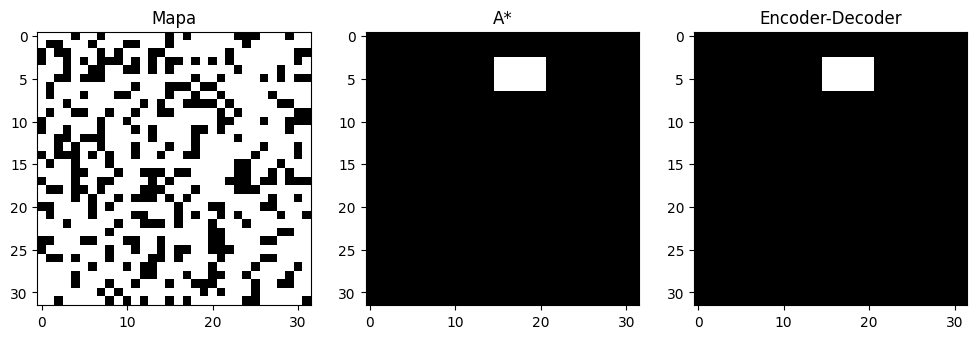

In [ ]:
idx = np.random.randint(
    len(X_test)
)

pred = model.predict(
    X_test[idx:idx+1]
)[0,:,:,0]

real = Y_test[idx,:,:,0]

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(
    X_test[idx,:,:,0],
    cmap='gray_r'
)
plt.title("Mapa")

plt.subplot(132)
plt.imshow(
    real,
    cmap='gray'
)
plt.title("A*")

plt.subplot(133)
plt.imshow(
    pred > 0.5,
    cmap='gray'
)
plt.title("Encoder-Decoder")

plt.show()

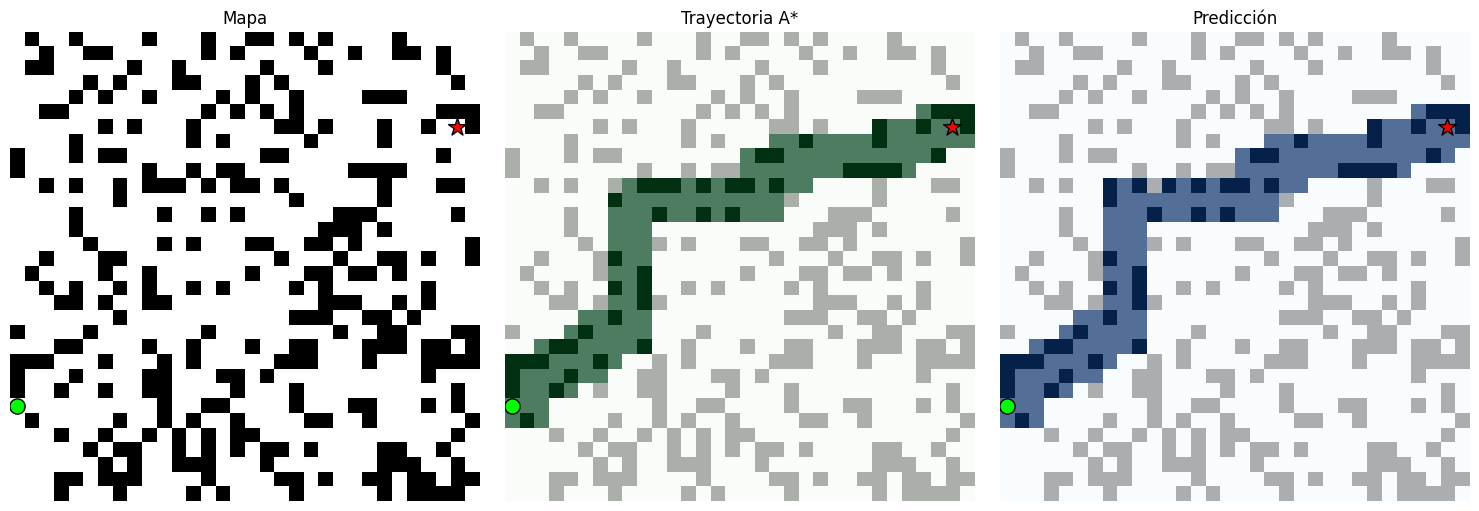

In [ ]:
idx = np.random.randint(len(X_test))

pred = model.predict(
    X_test[idx:idx+1],
    verbose=0
)[0,:,:,0]

real = Y_test[idx,:,:,0]

mapa = X_test[idx,:,:,0]
inicio = X_test[idx,:,:,1]
meta = X_test[idx,:,:,2]

# Coordenadas del inicio y meta
start_y, start_x = np.argwhere(inicio == 1)[0]
goal_y, goal_x = np.argwhere(meta == 1)[0]

pred_bin = (pred > 0.5).astype(np.float32)

plt.figure(figsize=(15,5))

# =====================================
# MAPA
# =====================================
plt.subplot(131)

plt.imshow(
    mapa,
    cmap='gray_r'
)

plt.scatter(
    start_x,
    start_y,
    c='lime',
    s=120,
    marker='o',
    edgecolors='black'
)

plt.scatter(
    goal_x,
    goal_y,
    c='red',
    s=180,
    marker='*',
    edgecolors='black'
)

plt.title("Mapa")
plt.axis('off')

# =====================================
# A*
# =====================================
plt.subplot(132)

plt.imshow(
    mapa,
    cmap='gray_r'
)

plt.imshow(
    real,
    cmap='Greens',
    alpha=0.7
)

plt.scatter(
    start_x,
    start_y,
    c='lime',
    s=120,
    marker='o',
    edgecolors='black'
)

plt.scatter(
    goal_x,
    goal_y,
    c='red',
    s=180,
    marker='*',
    edgecolors='black'
)

plt.title("Trayectoria A*")
plt.axis('off')

# =====================================
# PREDICCIÓN
# =====================================
plt.subplot(133)

plt.imshow(
    mapa,
    cmap='gray_r'
)

plt.imshow(
    pred_bin,
    cmap='Blues',
    alpha=0.7
)

plt.scatter(
    start_x,
    start_y,
    c='lime',
    s=120,
    marker='o',
    edgecolors='black'
)

plt.scatter(
    goal_x,
    goal_y,
    c='red',
    s=180,
    marker='*',
    edgecolors='black'
)

plt.title("Predicción")
plt.axis('off')

plt.tight_layout()
plt.show()

## Discriminador

In [ ]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

def build_discriminator(input_size=32):

    inp = Input(
        shape=(input_size,input_size,4)
    )

    x = Conv2D(
        64,
        4,
        strides=2,
        padding='same'
    )(inp)

    x = LeakyReLU(0.2)(x)

    x = Conv2D(
        128,
        4,
        strides=2,
        padding='same'
    )(x)

    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    x = Conv2D(
        256,
        4,
        padding='same'
    )(x)

    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    output = Conv2D(
        1,
        4,
        padding='same',
        activation='sigmoid'
    )(x)

    return Model(inp, output)

In [ ]:
discriminator = build_discriminator(
    input_size=input_size
)

discriminator.compile(
    optimizer=tf.keras.optimizers.Adam(
        2e-4,
        beta_1=0.5
    ),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

generator = model

## GAN

In [ ]:
discriminator.trainable = False

gan_input = Input(
    shape=(input_size,input_size,3)
)

fake_path = generator(
    gan_input
)

gan_concat = Concatenate(axis=-1)(
    [
        gan_input,
        fake_path
    ]
)

gan_output = discriminator(
    gan_concat
)

gan = Model(
    gan_input,
    [
        fake_path,
        gan_output
    ]
)

gan.compile(
    optimizer=tf.keras.optimizers.Adam(
        2e-4,
        beta_1=0.5
    ),
    loss=[
        bce_dice_loss,
        'binary_crossentropy'
    ],
    loss_weights=[
        100,
        1
    ]
)

In [ ]:
epochs = 20
batch_size = 32

for epoch in range(epochs):

    n_batches = X_train.shape[0] // batch_size

    for batch in range(n_batches):

        idx = np.random.randint(
            0,
            X_train.shape[0],
            batch_size
        )

        X_batch = X_train[idx]
        Y_batch = Y_train[idx]

        # -------------------------
        # Generar trayectorias falsas
        # -------------------------

        fake_paths = generator.predict(
            X_batch,
            verbose=0
        )

        # -------------------------
        # Datos reales
        # -------------------------

        real_pairs = np.concatenate(
            [X_batch, Y_batch],
            axis=-1
        )

        # -------------------------
        # Datos falsos
        # -------------------------

        fake_pairs = np.concatenate(
            [X_batch, fake_paths],
            axis=-1
        )

        real_labels = np.ones(
            discriminator.output_shape[1:]
        )

        fake_labels = np.zeros(
            discriminator.output_shape[1:]
        )

        real_labels = np.repeat(
            real_labels[np.newaxis,...],
            batch_size,
            axis=0
        )

        fake_labels = np.repeat(
            fake_labels[np.newaxis,...],
            batch_size,
            axis=0
        )

        # -------------------------
        # Entrenar discriminador
        # -------------------------

        discriminator.trainable = True

        d_loss_real = discriminator.train_on_batch(
            real_pairs,
            real_labels
        )

        d_loss_fake = discriminator.train_on_batch(
            fake_pairs,
            fake_labels
        )

        # -------------------------
        # Entrenar generador
        # -------------------------

        discriminator.trainable = False

        g_loss = gan.train_on_batch(
            X_batch,
            [
                Y_batch,
                real_labels
            ]
        )

    print(
        f"Epoch {epoch+1}/{epochs}"
        f" | D_real={d_loss_real[0]:.4f}"
        f" | D_fake={d_loss_fake[0]:.4f}"
        f" | G={g_loss[0]:.4f}"
    )

    print("REAL:", d_loss_real)
    print("FAKE:", d_loss_fake)

Epoch 1/20 | D_real=0.7151 | D_fake=0.7151 | G=7.9700
Epoch 2/20 | D_real=0.7113 | D_fake=0.7113 | G=7.4109
Epoch 3/20 | D_real=0.7090 | D_fake=0.7090 | G=7.0221
Epoch 4/20 | D_real=0.7069 | D_fake=0.7069 | G=6.6429
Epoch 5/20 | D_real=0.7051 | D_fake=0.7051 | G=6.3249
Epoch 6/20 | D_real=0.7015 | D_fake=0.7015 | G=6.0457
Epoch 7/20 | D_real=0.6658 | D_fake=0.6658 | G=5.8542
Epoch 8/20 | D_real=0.6127 | D_fake=0.6127 | G=5.9220
Epoch 9/20 | D_real=0.5831 | D_fake=0.5831 | G=5.9467
Epoch 10/20 | D_real=0.5656 | D_fake=0.5656 | G=5.9321
Epoch 11/20 | D_real=0.5482 | D_fake=0.5482 | G=5.9241
Epoch 12/20 | D_real=0.5368 | D_fake=0.5368 | G=5.8822
Epoch 13/20 | D_real=0.5153 | D_fake=0.5153 | G=5.9421
Epoch 14/20 | D_real=0.5023 | D_fake=0.5023 | G=5.9558
Epoch 15/20 | D_real=0.4885 | D_fake=0.4885 | G=5.9896
Epoch 16/20 | D_real=0.4880 | D_fake=0.4880 | G=5.9017
Epoch 17/20 | D_real=0.4753 | D_fake=0.4753 | G=5.9300
Epoch 18/20 | D_real=0.4733 | D_fake=0.4733 | G=5.8764
Epoch 19/20 | D_rea

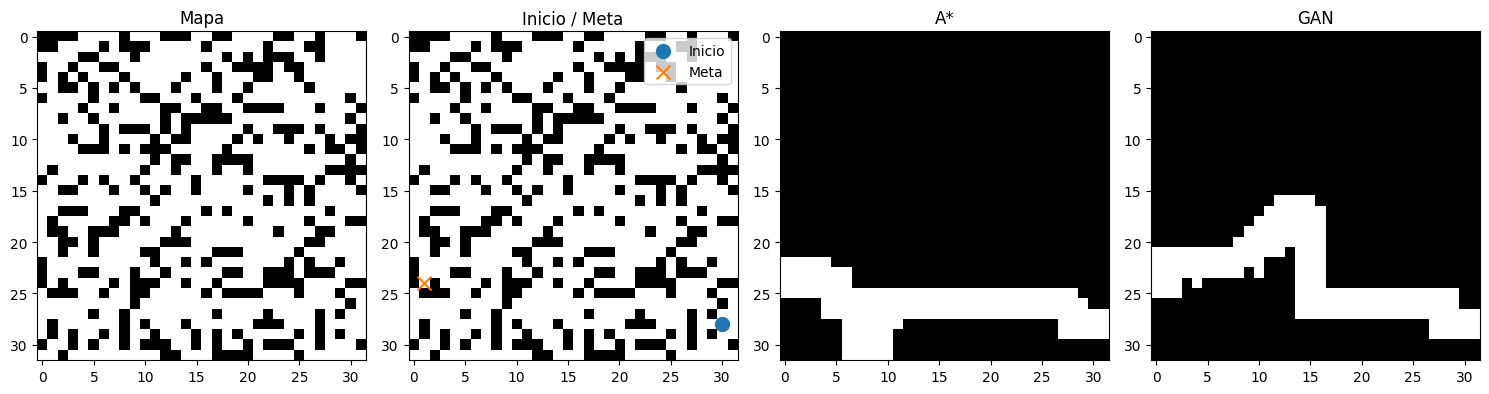

In [ ]:
idx = np.random.randint(len(X_test))

sample = X_test[idx:idx+1]

pred = generator.predict(
    sample,
    verbose=0
)

pred_mask = pred[0,:,:,0]

pred_bin = (
    pred_mask > 0.5
).astype(np.float32)

real = Y_test[idx,:,:,0]

mapa = X_test[idx,:,:,0]
inicio = X_test[idx,:,:,1]
meta = X_test[idx,:,:,2]

plt.figure(figsize=(15,4))

# ==========================
# Mapa
# ==========================
plt.subplot(1,4,1)
plt.imshow(mapa, cmap='gray_r')
plt.title("Mapa")

# ==========================
# Inicio y meta
# ==========================
plt.subplot(1,4,2)
plt.imshow(mapa, cmap='gray_r')

y_start, x_start = np.where(inicio == 1)
y_goal, x_goal = np.where(meta == 1)

plt.scatter(
    x_start,
    y_start,
    marker='o',
    s=100,
    label='Inicio'
)

plt.scatter(
    x_goal,
    y_goal,
    marker='x',
    s=100,
    label='Meta'
)

plt.legend()
plt.title("Inicio / Meta")

# ==========================
# Trayectoria A*
# ==========================
plt.subplot(1,4,3)
plt.imshow(real, cmap='gray')
plt.title("A*")

# ==========================
# Predicción GAN
# ==========================
plt.subplot(1,4,4)
plt.imshow(pred_bin, cmap='gray')
plt.title("GAN")

plt.tight_layout()
plt.show()

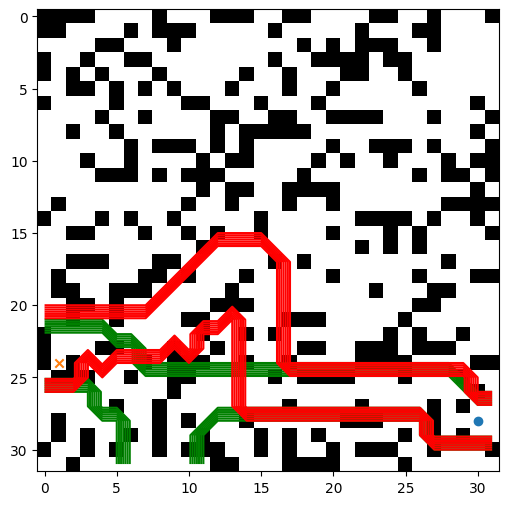

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(
    mapa,
    cmap='gray_r'
)

plt.contour(
    real,
    colors='green'
)

plt.contour(
    pred_bin,
    colors='red'
)

start_pos = np.argwhere(
    inicio > 0.5
)[0]

plt.scatter(
    start_pos[1],
    start_pos[0],
    marker='o'
)

goal_pos = np.argwhere(
    meta > 0.5
)[0]

plt.scatter(
    goal_pos[1],
    goal_pos[0],
    marker='x'
)

plt.show()

In [ ]:
pred_test = generator.predict(
    X_test,
    verbose=0
)
pred_test = (
    pred_test > 0.5
).astype(np.float32)

dice_scores = []

for i in range(len(X_test)):

    y_true = Y_test[i].flatten()

    y_pred = pred_test[i].flatten()

    intersection = np.sum(
        y_true * y_pred
    )

    dice = (
        2*intersection + 1e-6
    ) / (
        np.sum(y_true)
        + np.sum(y_pred)
        + 1e-6
    )

    dice_scores.append(
        dice
    )

print(
"Dice promedio:",
np.mean(dice_scores)
)

Dice promedio: 0.917613


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Predicciones del generador
# ==========================================

pred_test = generator.predict(
    X_test,
    verbose=0
)

pred_bin = (
    pred_test > 0.5
).astype(np.float32)

# ==========================================
# Métricas
# ==========================================

dice_scores = []
iou_scores = []
realism_scores = []

valid_paths = 0

for i in range(len(X_test)):

    y_true = Y_test[i,:,:,0]
    y_pred = pred_bin[i,:,:,0]

    # --------------------------------------
    # Dice
    # --------------------------------------

    intersection = np.sum(
        y_true * y_pred
    )

    dice = (
        2.0 * intersection + 1e-6
    ) / (
        np.sum(y_true)
        + np.sum(y_pred)
        + 1e-6
    )

    dice_scores.append(dice)

    # --------------------------------------
    # IoU
    # --------------------------------------

    union = np.sum(
        (y_true + y_pred) > 0
    )

    iou = (
        intersection + 1e-6
    ) / (
        union + 1e-6
    )

    iou_scores.append(iou)

    # --------------------------------------
    # Validez de trayectoria
    # --------------------------------------

    mapa = X_test[i,:,:,0]

    collision = np.any(
        (y_pred == 1)
        &
        (mapa == 1)
    )

    if not collision:
        valid_paths += 1

    # --------------------------------------
    # Discriminador
    # --------------------------------------

    pair = np.concatenate(
        [
            X_test[i:i+1],
            pred_test[i:i+1]
        ],
        axis=-1
    )

    realism = discriminator.predict(
        pair,
        verbose=0
    )

    realism_scores.append(
        np.mean(realism)
    )

# ==========================================
# Resultados globales
# ==========================================

print("\n========== RESULTADOS ==========")

print(
    f"Dice promedio: {np.mean(dice_scores):.4f}"
)

print(
    f"IoU promedio: {np.mean(iou_scores):.4f}"
)

print(
    f"Trayectorias válidas: "
    f"{100*valid_paths/len(X_test):.2f}%"
)

print(
    f"Realismo promedio: "
    f"{np.mean(realism_scores):.4f}"
)


========== RESULTADOS ==========
Dice promedio: 0.9176
IoU promedio: 0.8755
Trayectorias válidas: 0.05%
Realismo promedio: 0.0125


Mejor Dice: 1.0


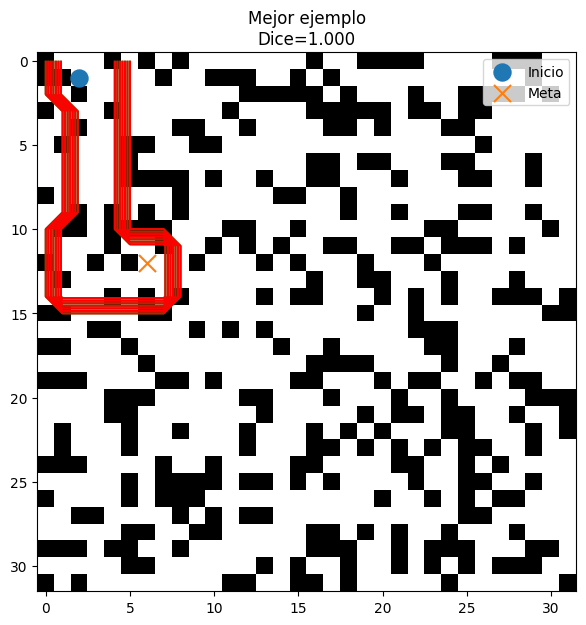

In [ ]:
best_idx = np.argmax(dice_scores)

print(
    "Mejor Dice:",
    dice_scores[best_idx]
)

mapa = X_test[best_idx,:,:,0]
inicio = X_test[best_idx,:,:,1]
meta = X_test[best_idx,:,:,2]

real = Y_test[best_idx,:,:,0]
pred = pred_bin[best_idx,:,:,0]

plt.figure(figsize=(7,7))

plt.imshow(
    mapa,
    cmap='gray_r'
)

plt.contour(
    real,
    colors='green'
)

plt.contour(
    pred,
    colors='red'
)

start_pos = np.argwhere(
    inicio > 0.5
)[0]

goal_pos = np.argwhere(
    meta > 0.5
)[0]

plt.scatter(
    start_pos[1],
    start_pos[0],
    marker='o',
    s=150,
    label='Inicio'
)

plt.scatter(
    goal_pos[1],
    goal_pos[0],
    marker='x',
    s=150,
    label='Meta'
)

plt.legend()

plt.title(
    f"Mejor ejemplo\n"
    f"Dice={dice_scores[best_idx]:.3f}"
)

plt.show()

Peor Dice: 0.12048194


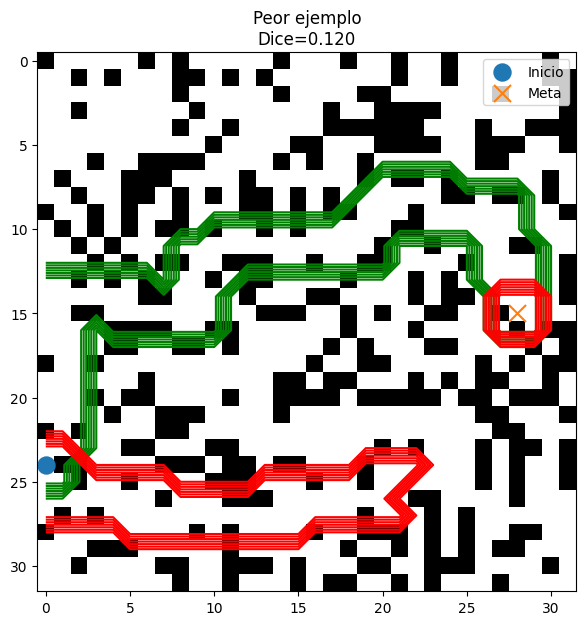

In [ ]:
worst_idx = np.argmin(dice_scores)

print(
    "Peor Dice:",
    dice_scores[worst_idx]
)
mapa = X_test[worst_idx,:,:,0]
inicio = X_test[worst_idx,:,:,1]
meta = X_test[worst_idx,:,:,2]

real = Y_test[worst_idx,:,:,0]
pred = pred_bin[worst_idx,:,:,0]

plt.figure(figsize=(7,7))

plt.imshow(
    mapa,
    cmap='gray_r'
)

plt.contour(
    real,
    colors='green'
)

plt.contour(
    pred,
    colors='red'
)

start_pos = np.argwhere(
    inicio > 0.5
)[0]

goal_pos = np.argwhere(
    meta > 0.5
)[0]

plt.scatter(
    start_pos[1],
    start_pos[0],
    marker='o',
    s=150,
    label='Inicio'
)

plt.scatter(
    goal_pos[1],
    goal_pos[0],
    marker='x',
    s=150,
    label='Meta'
)

plt.legend()

plt.title(
    f"Peor ejemplo\n"
    f"Dice={dice_scores[worst_idx]:.3f}"
)

plt.show()

In [ ]:
path_pixels = np.sum(y_pred)

path_pixels_real = np.sum(y_true)

error_longitud = abs(
    path_pixels - path_pixels_real
)